In [2]:
import numpy as np
from tqdm.notebook import tqdm
from src.synths.dsp import compute_ksa_rt60, FS_MIN, LAGRANGE_ORDER

FS = FS_MIN
N_lines = 200
N_freqs = 100

f0_vals = np.geomspace(80, 1280, N_freqs)
a1_sweep = np.geomspace(0.001, 0.1, N_lines)
g_sweep = 1 - a1_sweep

rt60_curves = np.array([
    [compute_ksa_rt60(f0=f, a1=a1, g=g, fs=FS, lagrange_order=LAGRANGE_ORDER)
     for f in f0_vals]
    for a1, g in tqdm(zip(a1_sweep, g_sweep), total=N_lines, desc="Computing RT60 curves")
])

Computing RT60 curves:   0%|          | 0/200 [00:00<?, ?it/s]

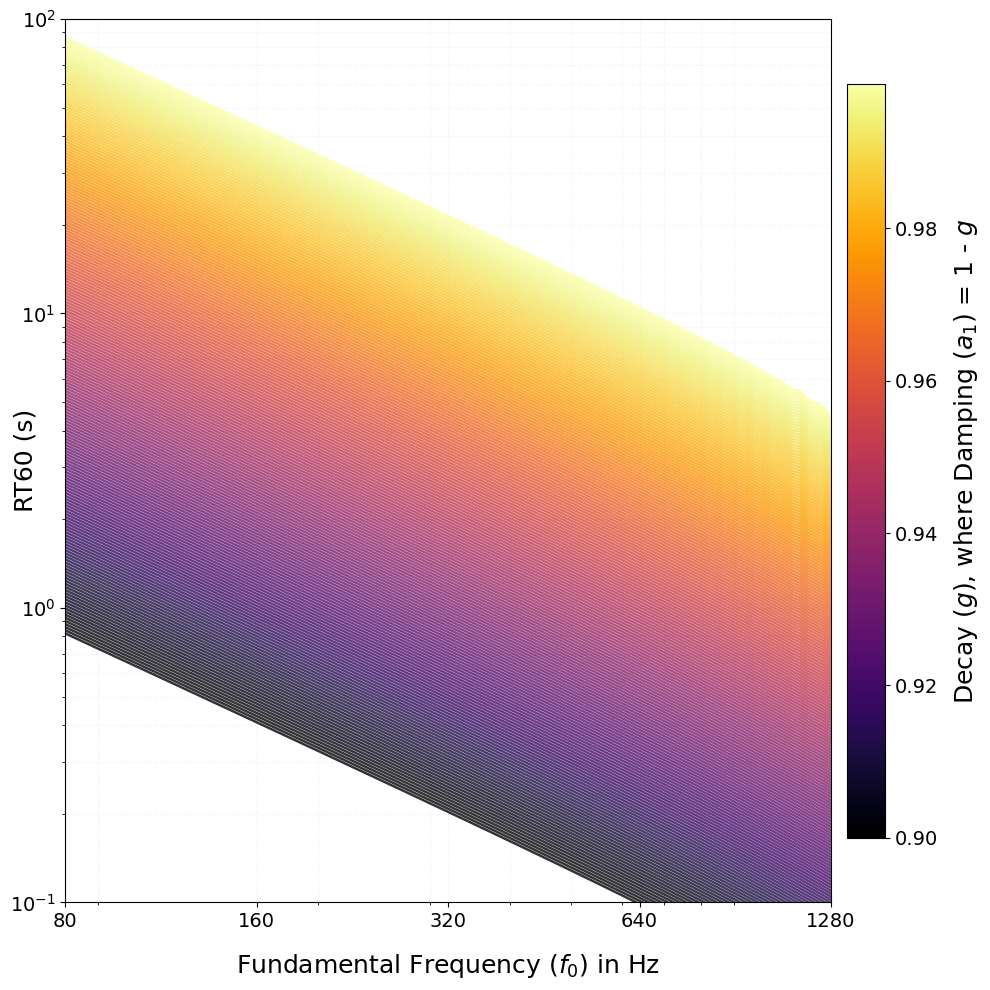

For g=0.999, a1=0.001:
RT60 at 80 Hz: 86.26s
RT60 at 1280 Hz: 4.50s


In [10]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# --- Tweak these for size and spacing ---
base_fs = 18          # Base font size for main labels
tick_fs = 14          # Font size for the numbers on the axes
y_label_dist = -20     # Increased to accommodate larger font
x_label_dist = 15
cbar_label_dist = 10
colorbar_pad = 0.02

cmap = plt.colormaps['inferno']

# Figure size (Narrow: Width=6, Height=10)
fig, ax = plt.subplots(figsize=(10, 10))

for i, rt60_vals in enumerate(rt60_curves):
    color_idx = 1.0 - (i / (len(rt60_curves) - 1))
    ax.plot(f0_vals, rt60_vals, color=cmap(color_idx), linewidth=1.8, alpha=0.8)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(80, 1280)
ax.set_ylim(0.1, 100)

# X-axis formatting
ax.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax.set_xticks([80, 160, 320, 640, 1280])
ax.yaxis.set_major_formatter(ticker.LogFormatterMathtext())
ax.tick_params(axis='both', which='major', labelsize=tick_fs)
ax.set_xlabel("Fundamental Frequency ($f_0$) in Hz", fontsize=base_fs, labelpad=x_label_dist)
ax.set_ylabel("RT60 (s)", fontsize=base_fs, labelpad=y_label_dist)
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(vmin=g_sweep.min(), vmax=g_sweep.max()))
cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=colorbar_pad)
cbar.set_label('Decay ($g$), where Damping ($a_1$) = 1 - $g$', fontsize=base_fs, labelpad=cbar_label_dist)
cbar.ax.tick_params(labelsize=tick_fs)

ax.grid(True, which="both", ls="--", alpha=0.1)

plt.tight_layout()
plt.savefig("fig_3.pdf", bbox_inches='tight')
plt.show()

most_resonant = rt60_curves[0]
low_f0_rt60 = most_resonant[0]
high_f0_rt60 = most_resonant[-1]

print(f"For g=0.999, a1=0.001:")
print(f"RT60 at {f0_vals[0]:.0f} Hz: {low_f0_rt60:.2f}s")
print(f"RT60 at {f0_vals[-1]:.0f} Hz: {high_f0_rt60:.2f}s")